# Day 8: Adding Elo Rating Features

In [52]:
import pandas as pd
import numpy as np

from pathlib import Path
from collections import defaultdict

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## Loading Data

In [38]:
def find_project_root():
    current = Path.cwd()

    for path in [current] + list(current.parents):
        if (path / "data").exists():
            return path

    raise FileNotFoundError("Could not find project root. Make sure this notebook is inside your project folder.")


PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", DATA_PROCESSED)

Project root: /Users/rayhanrinzan/fifa-world-cup-predictor
Processed data folder: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed


In [39]:
matches_path = DATA_PROCESSED / "matches_with_results.csv"

matches = pd.read_csv(matches_path)

matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,home_win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,home_win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,home_win


In [40]:
matches = matches.copy()
matches["date"] = pd.to_datetime(matches["date"])
matches = matches.sort_values("date").reset_index(drop=True)

## Creating Elo System

In [41]:
def expected_score(rating_a, rating_b):
    """
    Calculates Team A's expected score against Team B.
    Returns a number between 0 and 1.
    """
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating_a, rating_b, actual_a, k=30):
    """
    Updates Team A's Elo rating after a match.

    actual_a:
    1 = Team A won
    0.5 = draw
    0 = Team A lost
    """
    expected_a = expected_score(rating_a, rating_b)
    new_rating_a = rating_a + k * (actual_a - expected_a)
    return new_rating_a

In [42]:
elo_ratings = defaultdict(lambda: 1500)

elo_rows = []

for _, row in matches.iterrows():
    home_team = row["home_team"]
    away_team = row["away_team"]

    home_score = row["home_score"]
    away_score = row["away_score"]

    home_elo_before = elo_ratings[home_team]
    away_elo_before = elo_ratings[away_team]

    if home_score > away_score:
        home_actual = 1
        away_actual = 0
    elif home_score < away_score:
        home_actual = 0
        away_actual = 1
    else:
        home_actual = 0.5
        away_actual = 0.5

    home_elo_after = update_elo(
        home_elo_before,
        away_elo_before,
        home_actual,
        k=30
    )

    away_elo_after = update_elo(
        away_elo_before,
        home_elo_before,
        away_actual,
        k=30
    )

    elo_rows.append({
        "date": row["date"],
        "home_team": home_team,
        "away_team": away_team,
        "home_elo_before": home_elo_before,
        "away_elo_before": away_elo_before,
        "home_elo_after": home_elo_after,
        "away_elo_after": away_elo_after
    })

    elo_ratings[home_team] = home_elo_after
    elo_ratings[away_team] = away_elo_after


elo_df = pd.DataFrame(elo_rows)

elo_df.head()

,date,home_team,away_team,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,1500.000000,1500.000000,1515.000000,1485.000000
2,1874-03-07,Scotland,England,1485.000000,1515.000000,1501.291995,1498.708005
3,1875-03-06,England,Scotland,1498.708005,1501.291995,1498.819563,1501.180437
4,1876-03-04,Scotland,England,1501.180437,1498.819563,1516.078511,1483.921489


In [43]:
final_elo_df = pd.DataFrame(
    list(elo_ratings.items()),
    columns=["team", "final_elo"]
).sort_values("final_elo", ascending=False)

final_elo_df.head(20)

,team,final_elo
7,Argentina,2017.194119
40,Spain,2013.531931
12,France,1965.935691
48,Portugal,1929.013708
33,Brazil,1927.792444
21,Germany,1922.227469
1,England,1917.215235
85,Colombia,1915.070678
17,Netherlands,1901.872557
35,Japan,1896.789665


In [44]:
matchup_path = DATA_PROCESSED / "matchup_training_data.csv"
matchup_df = pd.read_csv(matchup_path)
matchup_df["date"] = pd.to_datetime(matchup_df["date"])

In [45]:
home_perspective_elo = elo_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_elo_before",
        "away_elo_before"
    ]
].copy()

home_perspective_elo = home_perspective_elo.rename(columns={
    "home_team": "team_a",
    "away_team": "team_b",
    "home_elo_before": "team_a_elo_before",
    "away_elo_before": "team_b_elo_before"
})


away_perspective_elo = elo_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_elo_before",
        "away_elo_before"
    ]
].copy()

away_perspective_elo = away_perspective_elo.rename(columns={
    "away_team": "team_a",
    "home_team": "team_b",
    "away_elo_before": "team_a_elo_before",
    "home_elo_before": "team_b_elo_before"
})


elo_matchup_format = pd.concat(
    [home_perspective_elo, away_perspective_elo],
    ignore_index=True
)

elo_matchup_format.head()

,date,team_a,team_b,team_a_elo_before,team_b_elo_before
0,1872-11-30,Scotland,England,1500.000000,1500.000000
1,1873-03-08,England,Scotland,1500.000000,1500.000000
2,1874-03-07,Scotland,England,1485.000000,1515.000000
3,1875-03-06,England,Scotland,1498.708005,1501.291995
4,1876-03-04,Scotland,England,1501.180437,1498.819563


In [46]:
matchup_with_elo = matchup_df.merge(
    elo_matchup_format,
    on=["date", "team_a", "team_b"],
    how="left"
)

In [47]:
matchup_with_elo["elo_diff"] = (
    matchup_with_elo["team_a_elo_before"]
    - matchup_with_elo["team_b_elo_before"]
)

matchup_with_elo[
    [
        "date",
        "team_a",
        "team_b",
        "team_a_elo_before",
        "team_b_elo_before",
        "elo_diff",
        "target"
    ]
].head(10)

,date,team_a,team_b,team_a_elo_before,team_b_elo_before,elo_diff,target
0,2012-09-25,Abkhazia,Artsakh,1500.000000,1500.000000,0.000000,draw
1,2013-09-23,Abkhazia,South Ossetia,1485.000000,1500.000000,-15.000000,win
2,2014-06-01,Abkhazia,Occitania,1500.647200,1604.855538,-104.208338,draw
3,2014-06-04,Abkhazia,South Ossetia,1520.262529,1488.777514,31.485016,draw
4,2014-06-07,Abkhazia,Occitania,1523.686006,1606.252643,-82.566636,loss
5,2015-05-05,Abkhazia,Luhansk PR,1512.185071,1500.000000,12.185071,win
6,2015-05-14,Abkhazia,Donetsk PR,1526.659214,1500.000000,26.659214,win
7,2016-05-21,Abkhazia,Donetsk PR,1540.510497,1487.389431,53.121066,draw
8,2016-05-29,Abkhazia,Chagos Islands,1538.234782,1492.781517,45.453264,win
9,2016-05-31,Abkhazia,Western Armenia,1551.283526,1514.125985,37.157541,win


In [48]:
output_path = DATA_PROCESSED / "matchup_training_data_with_elo.csv"

matchup_with_elo.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/rayhanrinzan/fifa-world-cup-predictor/data/processed/matchup_training_data_with_elo.csv


In [49]:
df = matchup_with_elo.copy()

features_with_elo = [
    "last_5_points_per_match_diff",
    "last_5_goals_for_per_match_diff",
    "last_5_goals_against_per_match_diff",
    "last_5_goal_difference_per_match_diff",
    "last_5_win_diff",
    "last_5_draw_diff",
    "last_5_loss_diff",
    "elo_diff"
]

target = "target"

In [50]:
train_df = df[df["date"] < "2018-01-01"].copy()
test_df = df[df["date"] >= "2018-01-01"].copy()

X_train = train_df[features_with_elo]
y_train = train_df[target]

X_test = test_df[features_with_elo]
y_test = test_df[target]

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTest distribution:")
print(y_test.value_counts())

Train size: 41333
Test size: 8159

Test distribution:
target
win     3866
loss    2359
draw    1934
Name: count, dtype: int64


In [53]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

elo_models = {
    "gradient_boosting_balanced_with_elo": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "hist_gradient_boosting_balanced_with_elo": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ),

    "logistic_balanced_with_elo": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

## Retraining Models with Elo

In [54]:
elo_results = []

for name, model in elo_models.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    if "boosting" in name:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    pred_counts = pd.Series(y_pred).value_counts()

    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nPrediction counts:")
    print(pred_counts)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=["win", "draw", "loss"]))

    elo_results.append({
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "win_f1": report["win"]["f1-score"],
        "draw_f1": report["draw"]["f1-score"],
        "loss_f1": report["loss"]["f1-score"],
        "predicted_wins": pred_counts.get("win", 0),
        "predicted_draws": pred_counts.get("draw", 0),
        "predicted_losses": pred_counts.get("loss", 0)
    })

gradient_boosting_balanced_with_elo
Accuracy: 0.5664909915430812
Macro F1: 0.5264780548014644
Weighted F1: 0.567422478653306

Prediction counts:
win     3760
loss    2450
draw    1949
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.31      0.31      0.31      1934
        loss       0.57      0.59      0.58      2359
         win       0.70      0.68      0.69      3866

    accuracy                           0.57      8159
   macro avg       0.53      0.53      0.53      8159
weighted avg       0.57      0.57      0.57      8159


Confusion matrix:
[[2620  787  459]
 [ 741  602  591]
 [ 399  560 1400]]
hist_gradient_boosting_balanced_with_elo
Accuracy: 0.5691874004167178
Macro F1: 0.5252893541471413
Weighted F1: 0.5674539411128203

Prediction counts:
win     3803
loss    2544
draw    1812
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw    

In [55]:
elo_results_df = pd.DataFrame(elo_results)

elo_results_df = elo_results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

elo_results_df

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
0,gradient_boosting_balanced_with_elo,0.566491,0.526478,0.567422,0.687123,0.310070,0.582242,3760,1949,2450
1,hist_gradient_boosting_balanced_with_elo,0.569187,0.525289,0.567454,0.690051,0.300053,0.585764,3803,1812,2544
2,logistic_balanced_with_elo,0.576174,0.525117,0.569378,0.696096,0.281690,0.597566,3972,1616,2571


In [56]:
old_best_results = pd.DataFrame([
    {
        "model": "gradient_boosting_balanced_no_elo",
        "accuracy": 0.457633,
        "macro_f1": 0.448471,
        "weighted_f1": 0.471614,
        "win_f1": 0.552884,
        "draw_f1": 0.313717,
        "loss_f1": 0.468013,
        "predicted_wins": 2917,
        "predicted_draws": 2892,
        "predicted_losses": 2346
    },
    {
        "model": "hist_gradient_boosting_balanced_no_elo",
        "accuracy": 0.458124,
        "macro_f1": 0.444378,
        "weighted_f1": 0.471569,
        "win_f1": 0.553260,
        "draw_f1": 0.307692,
        "loss_f1": 0.472181,
        "predicted_wins": 2963,
        "predicted_draws": 2824,
        "predicted_losses": 2368
    },
    {
        "model": "logistic_balanced_no_elo",
        "accuracy": 0.490374,
        "macro_f1": 0.443977,
        "weighted_f1": 0.484856,
        "win_f1": 0.606149,
        "draw_f1": 0.233083,
        "loss_f1": 0.492699,
        "predicted_wins": 3717,
        "predicted_draws": 1524,
        "predicted_losses": 2914
    }
])

In [57]:
elo_comparison_df = pd.concat(
    [old_best_results, elo_results_df],
    ignore_index=True
)

elo_comparison_df = elo_comparison_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

elo_comparison_df

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
3,gradient_boosting_balanced_with_elo,0.566491,0.526478,0.567422,0.687123,0.310070,0.582242,3760,1949,2450
4,hist_gradient_boosting_balanced_with_elo,0.569187,0.525289,0.567454,0.690051,0.300053,0.585764,3803,1812,2544
5,logistic_balanced_with_elo,0.576174,0.525117,0.569378,0.696096,0.281690,0.597566,3972,1616,2571
0,gradient_boosting_balanced_no_elo,0.457633,0.448471,0.471614,0.552884,0.313717,0.468013,2917,2892,2346
1,hist_gradient_boosting_balanced_no_elo,0.458124,0.444378,0.471569,0.553260,0.307692,0.472181,2963,2824,2368
2,logistic_balanced_no_elo,0.490374,0.443977,0.484856,0.606149,0.233083,0.492699,3717,1524,2914


## Visualizing Results

In [59]:
import matplotlib.pyplot as plt

models_to_plot = [
    "gradient_boosting_balanced",
    "hist_gradient_boosting_balanced",
    "logistic_balanced"
]

plot_rows = []

for base_model in models_to_plot:
    no_elo_name = base_model + "_no_elo"
    with_elo_name = base_model + "_with_elo"

    no_elo_row = elo_comparison_df[elo_comparison_df["model"] == no_elo_name]
    with_elo_row = elo_comparison_df[elo_comparison_df["model"] == with_elo_name]

    if len(no_elo_row) > 0:
        plot_rows.append({
            "model": base_model,
            "version": "No Elo",
            "macro_f1": no_elo_row["macro_f1"].iloc[0],
            "accuracy": no_elo_row["accuracy"].iloc[0],
            "draw_f1": no_elo_row["draw_f1"].iloc[0]
        })

    if len(with_elo_row) > 0:
        plot_rows.append({
            "model": base_model,
            "version": "With Elo",
            "macro_f1": with_elo_row["macro_f1"].iloc[0],
            "accuracy": with_elo_row["accuracy"].iloc[0],
            "draw_f1": with_elo_row["draw_f1"].iloc[0]
        })

plot_df = pd.DataFrame(plot_rows)

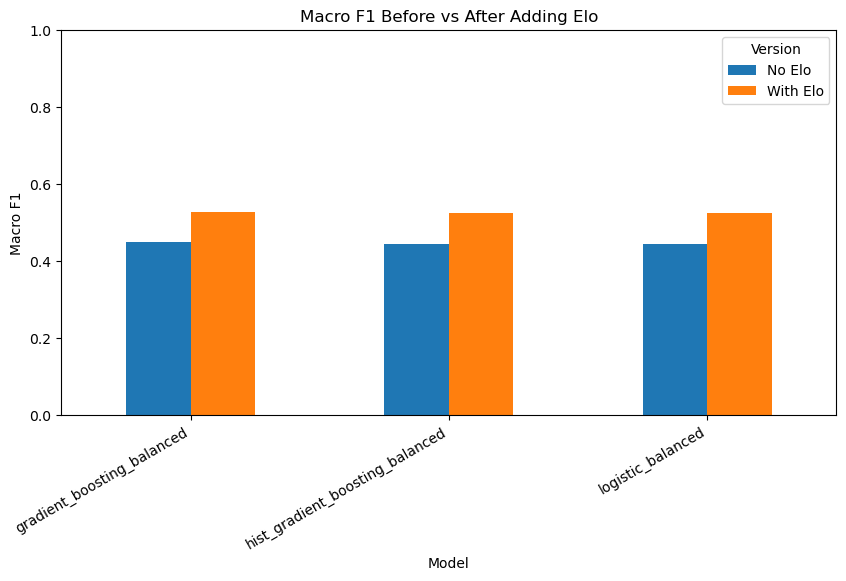

In [60]:
pivot_macro = plot_df.pivot(
    index="model",
    columns="version",
    values="macro_f1"
)

pivot_macro.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Macro F1 Before vs After Adding Elo")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Version")

plt.show()

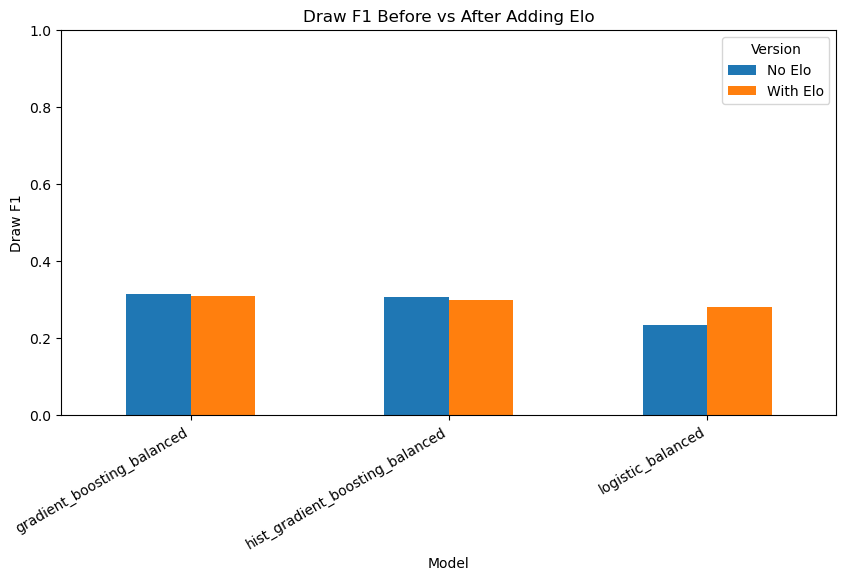

In [61]:
pivot_draw = plot_df.pivot(
    index="model",
    columns="version",
    values="draw_f1"
)

pivot_draw.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Draw F1 Before vs After Adding Elo")
plt.xlabel("Model")
plt.ylabel("Draw F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Version")

plt.show()

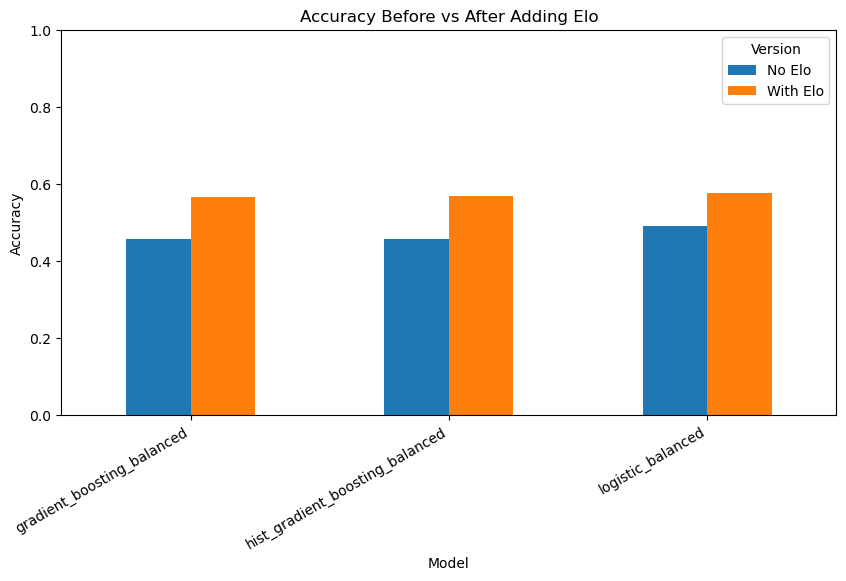

In [62]:
pivot_accuracy = plot_df.pivot(
    index="model",
    columns="version",
    values="accuracy"
)

pivot_accuracy.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Accuracy Before vs After Adding Elo")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Version")

plt.show()